In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [7]:
# ---------- 1) Load CSV ----------
csv_path = "seasonal_big_timeseries_5min_2023_2025.csv"  # update path if needed
df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp")
df.set_index("timestamp", inplace=True)
ts = df["value"]

In [8]:
# ---------- 2) Clean & Resample ----------
ts_interp = ts.interpolate(limit_direction="both")          # fill outages for modeling
daily = ts_interp.resample("D").mean()                      # aggregate to daily

C:\Users\sakib\AppData\Local\Temp\ipykernel_4884\1476259675.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window_end = window_start + pd.Timedelta(days=60)


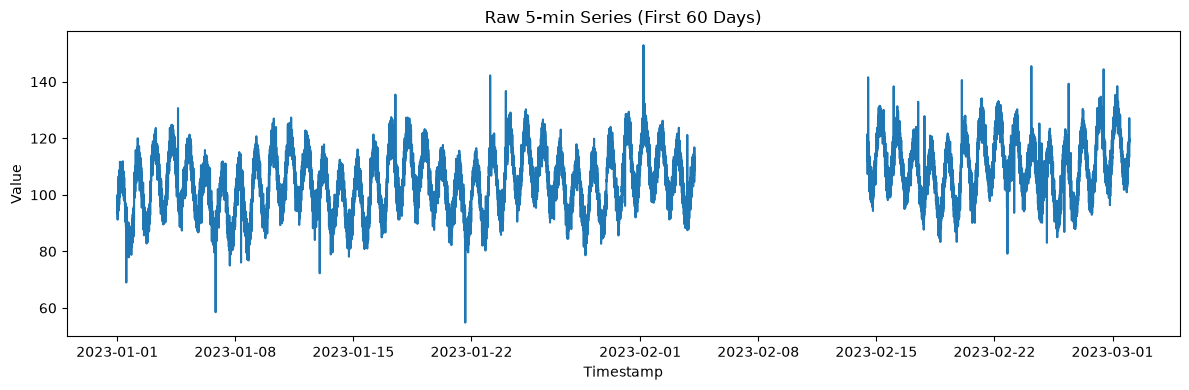

In [9]:
# ---------- 3) Visualizations ----------
# 3.1 Raw 5-min (first 60 days)
window_start = daily.index.min()
window_end = window_start + pd.Timedelta(days=60)
mask = (ts.index >= window_start) & (ts.index <= window_end)
plt.figure(figsize=(12,4)); plt.plot(ts.index[mask], ts.values[mask])
plt.title("Raw 5-min Series (First 60 Days)"); plt.xlabel("Timestamp"); plt.ylabel("Value")
plt.tight_layout(); plt.show()

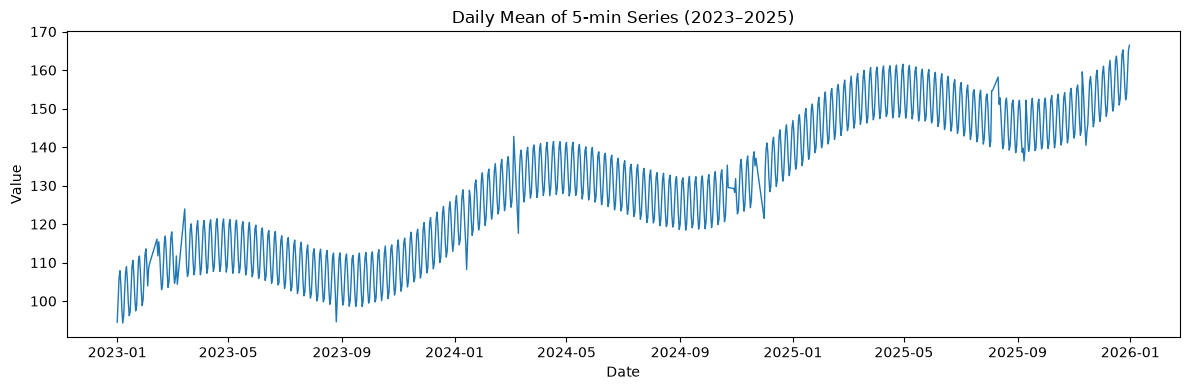

In [10]:
# 3.2 Daily plot (full period)
plt.figure(figsize=(12,4)); plt.plot(daily.index, daily.values, linewidth=1)
plt.title("Daily Mean of 5-min Series (2023–2025)"); plt.xlabel("Date"); plt.ylabel("Value")
plt.tight_layout(); plt.show()

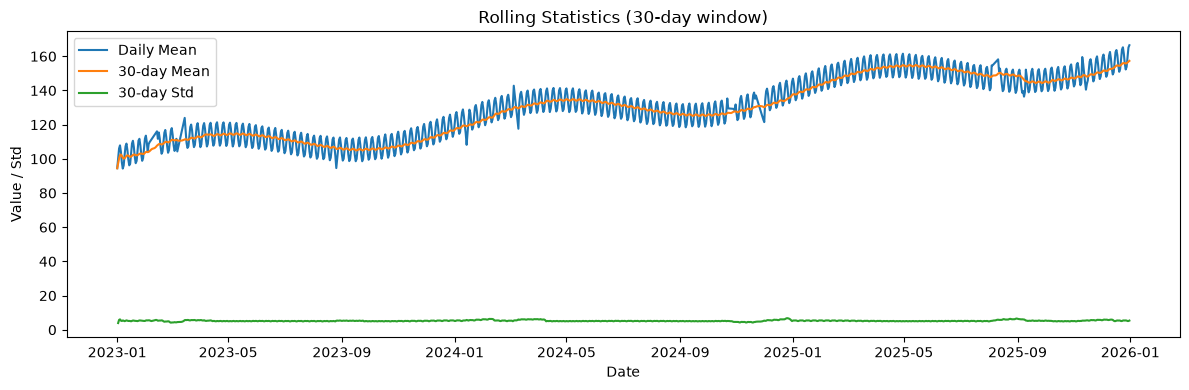

In [11]:
# 3.3 Rolling stats (30-day)
roll_mean = daily.rolling(30, min_periods=1).mean()
roll_std = daily.rolling(30, min_periods=1).std()
plt.figure(figsize=(12,4))
plt.plot(daily.index, daily.values, label="Daily Mean")
plt.plot(roll_mean.index, roll_mean.values, label="30-day Mean")
plt.plot(roll_std.index, roll_std.values, label="30-day Std")
plt.title("Rolling Statistics (30-day window)"); plt.xlabel("Date"); plt.ylabel("Value / Std")
plt.legend(); plt.tight_layout(); plt.show()

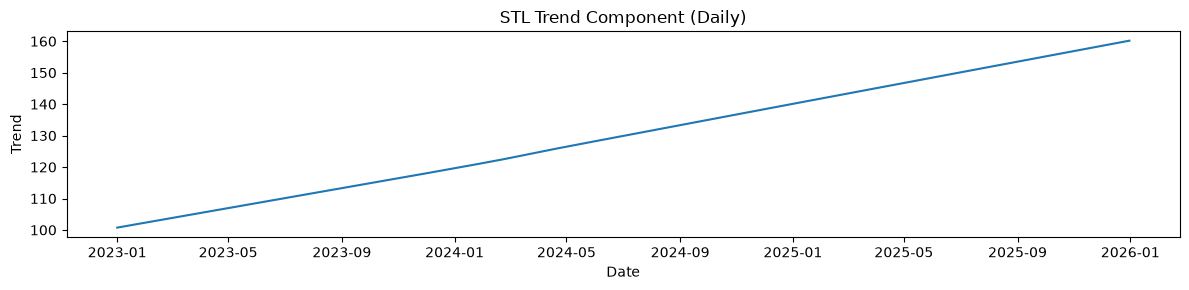

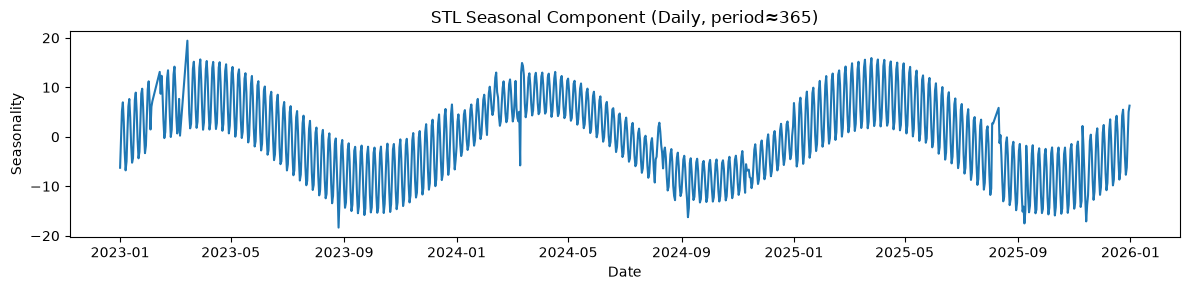

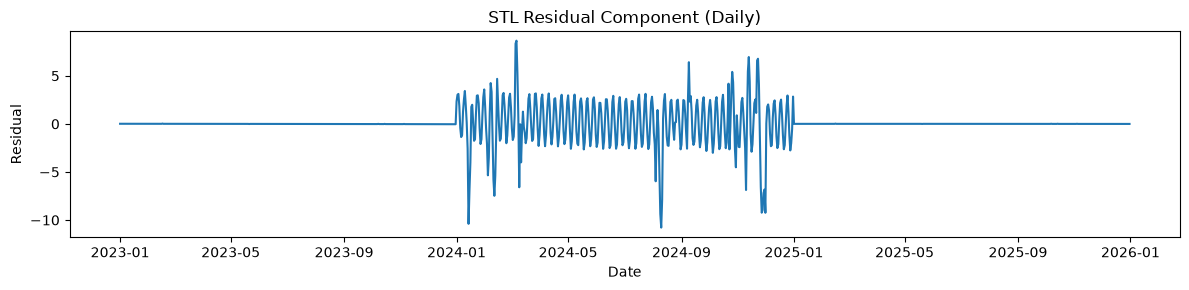

In [12]:
# ---------- 4) STL Decomposition ----------
stl = STL(daily, period=365, robust=True).fit()
plt.figure(figsize=(12,3)); plt.plot(daily.index, stl.trend.values)
plt.title("STL Trend Component (Daily)"); plt.xlabel("Date"); plt.ylabel("Trend")
plt.tight_layout(); plt.show()
plt.figure(figsize=(12,3)); plt.plot(daily.index, stl.seasonal.values)
plt.title("STL Seasonal Component (Daily, period≈365)"); plt.xlabel("Date"); plt.ylabel("Seasonality")
plt.tight_layout(); plt.show()
plt.figure(figsize=(12,3)); plt.plot(daily.index, stl.resid.values)
plt.title("STL Residual Component (Daily)"); plt.xlabel("Date"); plt.ylabel("Residual")
plt.tight_layout(); plt.show()

<Figure size 1000x400 with 0 Axes>

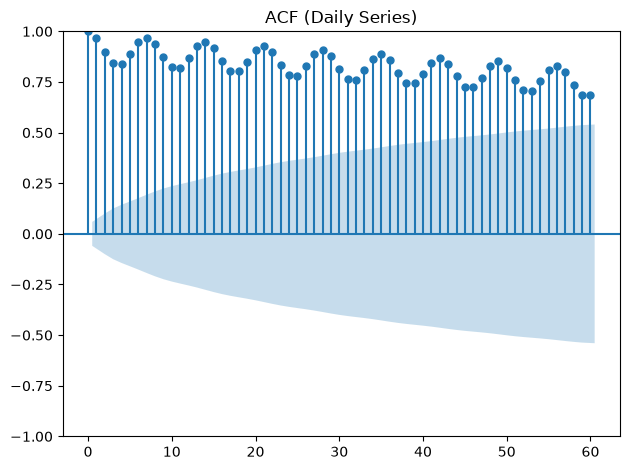

<Figure size 1000x400 with 0 Axes>

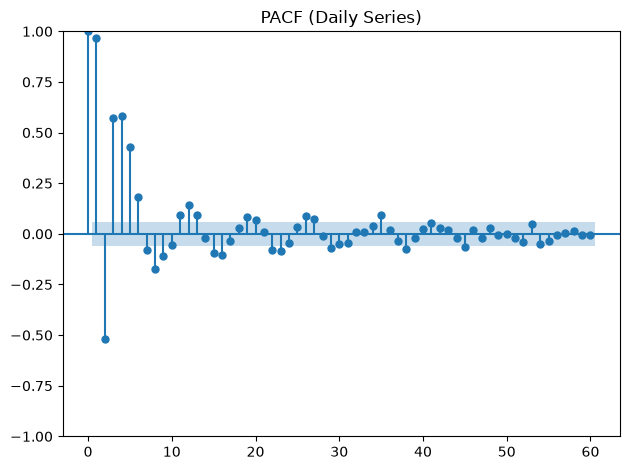

In [13]:
# ---------- 5) ACF & PACF ----------
plt.figure(figsize=(10,4)); plot_acf(daily.dropna(), lags=60)
plt.title("ACF (Daily Series)"); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,4)); plot_pacf(daily.dropna(), lags=60, method="ywm")
plt.title("PACF (Daily Series)"); plt.tight_layout(); plt.show()

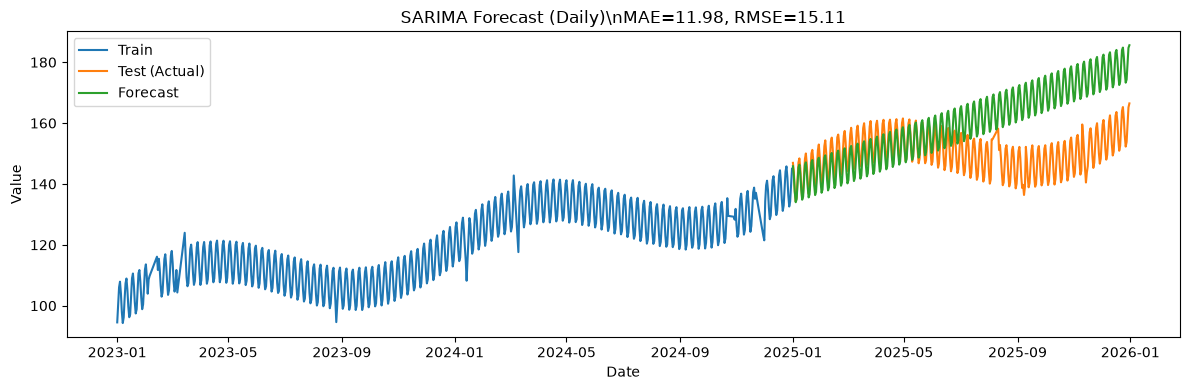

In [14]:
# ---------- 6) Train/Test & SARIMA ----------
train = daily.loc["2023":"2024"]
test = daily.loc["2025"]
model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,7),
                enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)

fcst = res.forecast(steps=len(test))
fcst.index = test.index

mae = mean_absolute_error(test, fcst)
rmse = math.sqrt(mean_squared_error(test, fcst))

plt.figure(figsize=(12,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test (Actual)")
plt.plot(fcst.index, fcst.values, label="Forecast")
plt.title(f"SARIMA Forecast (Daily)\\nMAE={mae:.2f}, RMSE={rmse:.2f}")
plt.xlabel("Date"); plt.ylabel("Value"); plt.legend()
plt.tight_layout(); plt.show()

C:\Users\sakib\AppData\Local\Temp\ipykernel_4884\2024688226.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  future_index = pd.date_range(daily.index[-1] + pd.Timedelta(days=1),


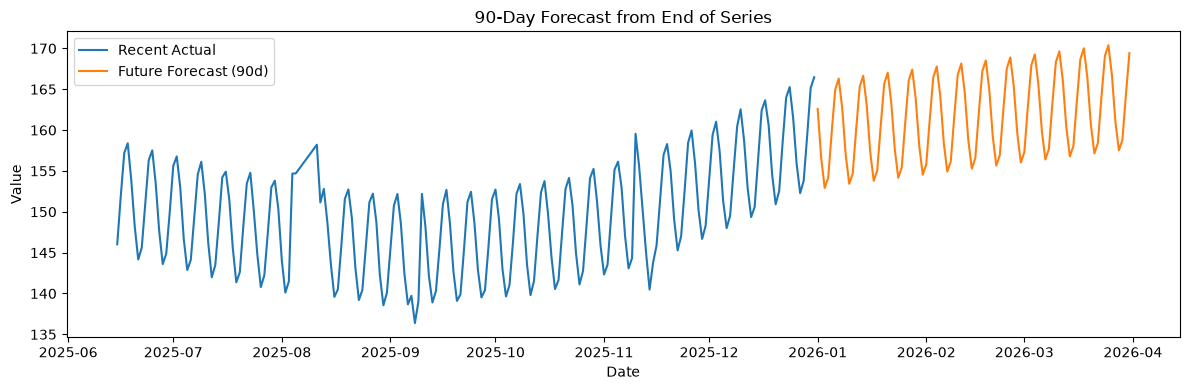

{'MAE': 11.976, 'RMSE': 15.115}


In [15]:
# ---------- 7) Future forecast ----------
model_full = SARIMAX(daily, order=(2,1,2), seasonal_order=(1,1,1,7),
                     enforce_stationarity=False, enforce_invertibility=False)
res_full = model_full.fit(disp=False)
future_steps = 90
future_fcst = res_full.forecast(steps=future_steps)
future_index = pd.date_range(daily.index[-1] + pd.Timedelta(days=1),
                             periods=future_steps, freq="D")

plt.figure(figsize=(12,4))
plt.plot(daily.index[-200:], daily.values[-200:], label="Recent Actual")
plt.plot(future_index, future_fcst.values, label="Future Forecast (90d)")
plt.title("90-Day Forecast from End of Series"); plt.xlabel("Date"); plt.ylabel("Value")
plt.legend(); plt.tight_layout(); plt.show()

print({"MAE": round(mae, 3), "RMSE": round(rmse, 3)})